In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

# only i am taking the numerical value 

In [111]:
df = pd.read_csv('A:\\AIML_DEV_FOLDER\\Dataset_self\\spotify_churn_dataset.csv')[
['age','listening_time','songs_played_per_day','skip_rate']]


In [112]:
df.shape

(8000, 4)

In [113]:
df.sample(5)

,age,listening_time,songs_played_per_day,skip_rate
6723,33,155,17,0.58
6047,52,297,63,0.10
1029,40,88,88,0.06
5521,47,180,62,0.24
4441,33,101,72,0.19


['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week','offline_listening', 
'is_churned']]


# Now i will draw with the for loop 
#### enumerate gives you both the index and value from a list.



In [114]:
items = ['a', 'b', 'c']
for index, value in enumerate(items):
    print(index, value)

0 a
1 b
2 c


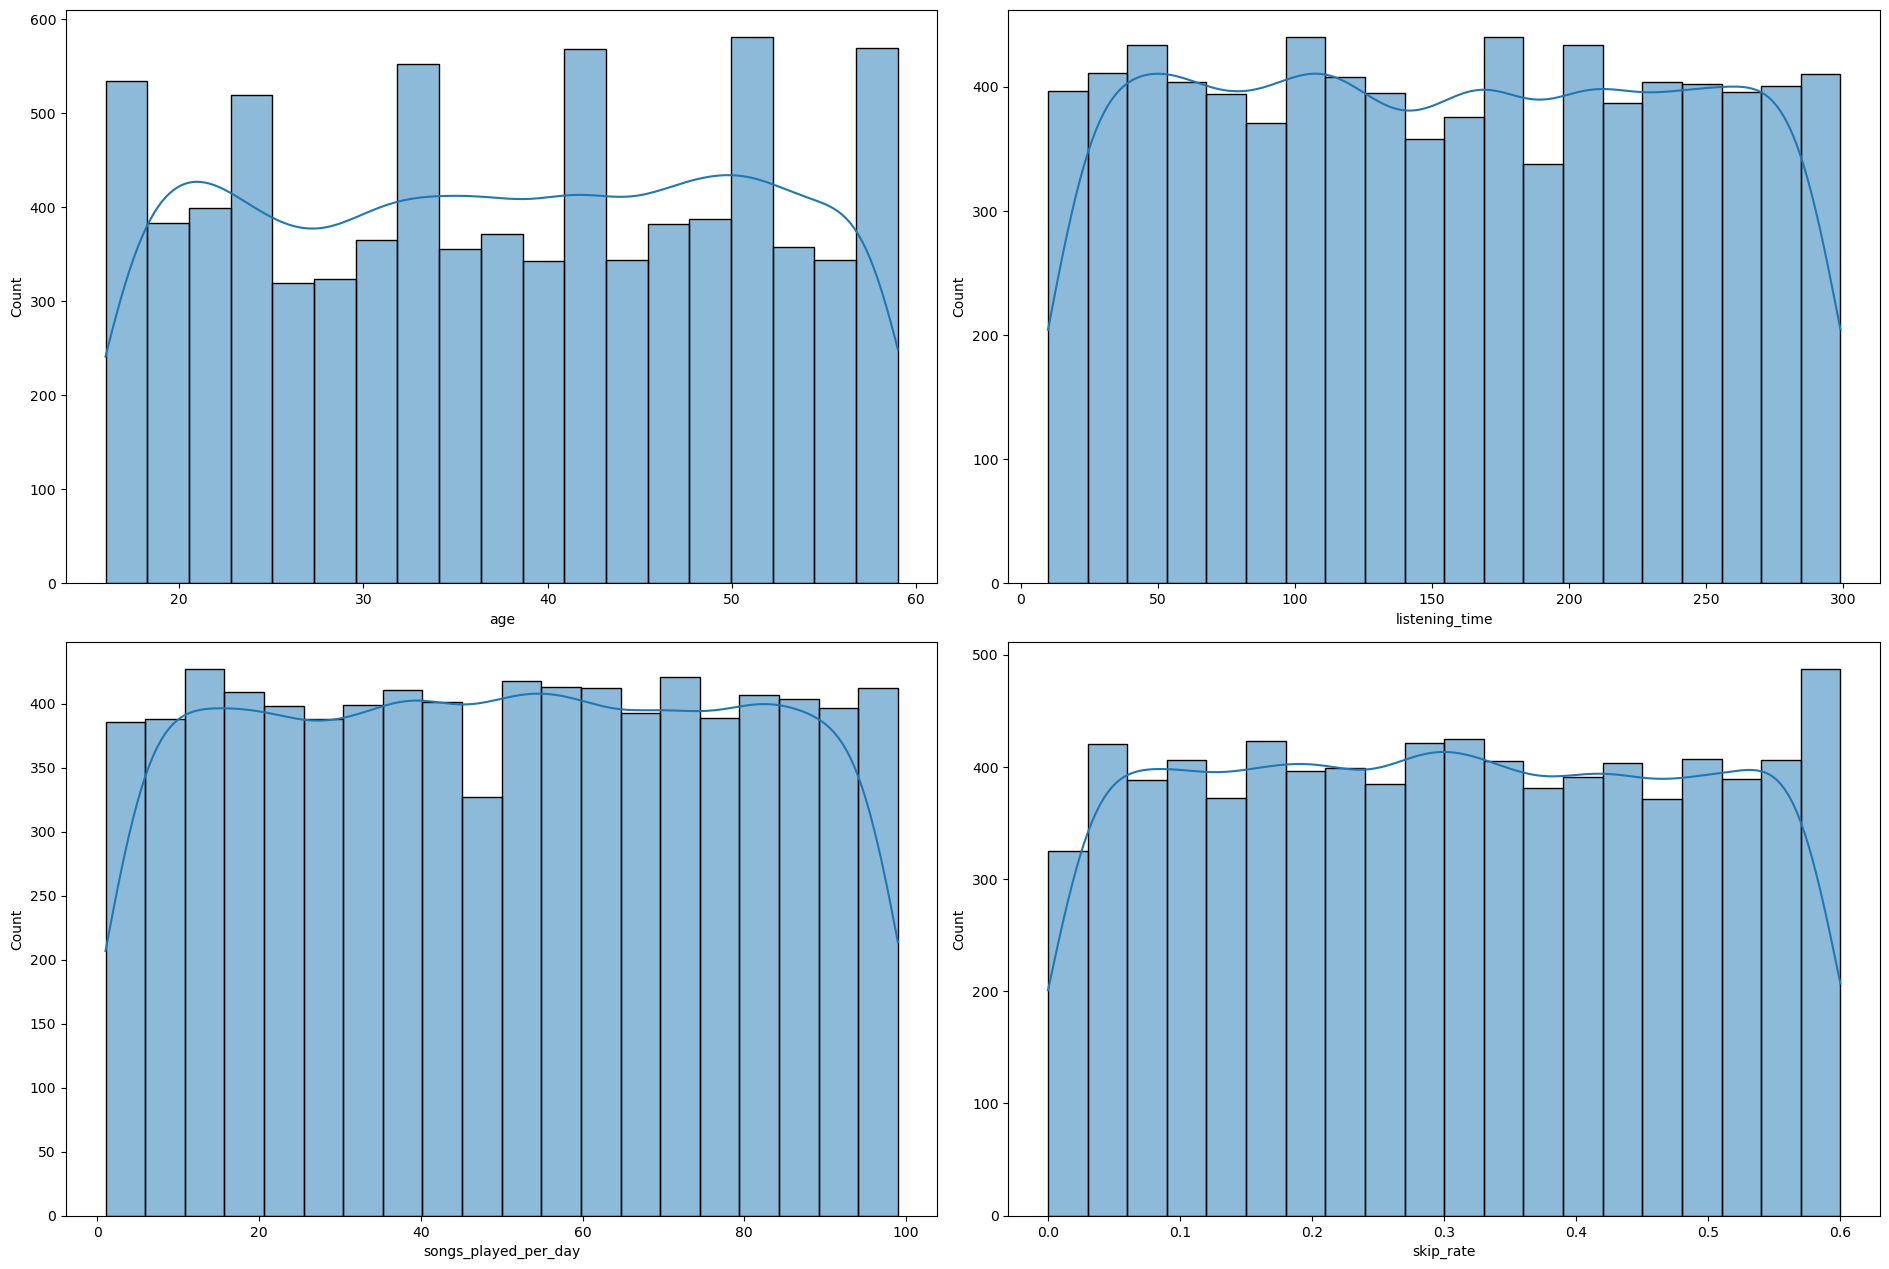

In [115]:

col =['age','listening_time','songs_played_per_day','skip_rate']
plt.figure(figsize=(19,25))
for i, col in enumerate(col, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True)

plt.tight_layout()
plt.show()

In [116]:

for i in col:
    print(df[col].skew())

0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093


# let check which sew data suite the most 


# log1p
 * Data has a zero or near zero value 
 * data has +ve skew data leaning toward right 
 * Values can be zero or very small




In [117]:
from sklearn.preprocessing import FunctionTransformer
transformer = FunctionTransformer(np.log1p)
df_log = transformer.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_log = pd.DataFrame(df_log, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

# orignal vs log 

In [118]:
df.sample(5)

,age,listening_time,songs_played_per_day,skip_rate
562,45,124,49,0.05
5493,41,86,19,0.26
2060,18,185,32,0.01
5943,42,188,35,0.15
5084,54,73,48,0.07


In [119]:
df_log.sample(5)

,age,listening_time,songs_played_per_day,skip_rate
866,3.583519,4.304065,2.079442,0.113329
689,3.970292,5.533389,3.806662,0.292670
6791,3.433987,5.214936,4.127134,0.277632
5828,3.688879,5.308268,4.110874,0.412110
189,3.912023,5.293305,1.609438,0.095310


In [120]:
for i in col:
    print(df_log[col].skew())

-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368
-0.15836141794592368


# np.sqrt

Use np.sqrt when:

Data has moderate positive skew

Values are non-negative (no negative numbers)

Less aggressive than log transformation

In [121]:
transformer2 = FunctionTransformer(np.sqrt)
df_sqrt = transformer2.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_sqrt = pd.DataFrame(df_sqrt, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

In [122]:
for i in col:
    print(df_sqrt[col].skew())

-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215
-0.5907228458732215


In [123]:
transformer3 = FunctionTransformer(np.sqrt)
df_sqrt = transformer2.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_sqrt = pd.DataFrame(df_sqrt, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

In [124]:
transformer3 = FunctionTransformer(np.sin)
df_sin = transformer3.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_sin = pd.DataFrame(df_sin, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

In [125]:
for i in col:
    print(df_sin[col].skew())

-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616
-0.05869343809671616


# lambda x: x 
is an identity function (returns input unchanged).

Use: When a transformer requires a function but you want no transformation.

Example: Testing pipeline without altering data

In [126]:
transformer4 = FunctionTransformer(lambda X:X)
df_lambda = transformer4.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_lambda = pd.DataFrame(df_lambda, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

In [127]:
for i in col:
    print(df_lambda[col].skew())

0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093


# power transformation
This is called a power transformation (specifically, squaring).

Used for:

Increasing skewness (makes positive skew more extreme)

Emphasizing larger values in the data

Sometimes for variance stabilization when variance increases with mean

In [128]:
transformer5 = FunctionTransformer(lambda X:X**2)
df_power = transformer5.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_power = pd.DataFrame(df_power, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])

In [129]:
for i in col:
    print(df_power[col].skew())

0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796
0.6473650316976796


# square root transformation:

Reduces positive skew

Less aggressive than log

For moderate right-skewed data

In [130]:
transformer6 = FunctionTransformer(lambda x:x**1/2)
df_Sqaure_root = transformer6.fit_transform(df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']])
df_Sqaure_root = pd.DataFrame(df_Sqaure_root, columns=['age', 'listening_time', 'songs_played_per_day', 'skip_rate'])


In [135]:
df_Sqaure_root.head()

,age,listening_time,songs_played_per_day,skip_rate
0,27.0,13.0,11.5,0.100
1,16.5,70.5,31.0,0.170
2,19.0,99.5,19.0,0.020
3,11.0,18.0,1.0,0.155
4,14.5,125.0,28.5,0.180


df_Sqaure_root

In [131]:
for i in col:
    print(df_Sqaure_root[col].skew())

0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093
0.005879643195667093


# note that its to check skew & adjust skewness of data 

# songs_played_per_day

In [136]:
print("Mean value of cgpa",df_Sqaure_root['songs_played_per_day'].mean())
print("Std value of cgpa",df_Sqaure_root['songs_played_per_day'].std())
print("Min value of cgpa",df_Sqaure_root['songs_played_per_day'].min())
print("Max value of cgpa",df_Sqaure_root['songs_played_per_day'].max())

Mean value of cgpa 25.063625
Std value of cgpa 14.224881203898827
Min value of cgpa 0.5
Max value of cgpa 49.5


# Find the highest and lowest point

In [ ]:
print("highest allowed ", df_Sqaure_root['songs_played_per_day'].mean()+df[''])